## ENEM-LLM-RAG — Classificação de Questões por Habilidade

Projeto de classificação de questões do ENEM (2009–2024) segundo a Matriz de Referência oficial (120 habilidades, 4 áreas de conhecimento), usando um LLM local (Ollama, gemma3:4b) com saída estruturada via Pydantic.

O objetivo é ir além do rótulo de disciplina (já disponível nos metadados) e atribuir a habilidade cognitiva específica exigida por cada questão — algo que não existe pronto nas bases públicas e que exige uma etapa de classificação semântica sobre o enunciado e a resposta correta.

Roteiro do notebook:

    Análise exploratória dos dados consolidados
    Organização e limpeza do dataset (múltiplas fontes, 2009–2024)
    Baseline de classificação clássica (TF-IDF + Regressão Logística) como teste de viabilidade
    Pipeline de classificação via LLM local, com schema estruturado, checkpointing e validação contra a matriz oficial


### Gráficos exploradores e com alguns resultados

Antes de qualquer modelagem, o objetivo aqui é entender três coisas: (1) o balanceamento das classes (disciplina, alternativa correta, distribuição por ano), (2) se o vocabulário das questões varia o suficiente entre disciplinas para justificar uma abordagem baseada em texto, e (3) problemas estruturais que podem limitar a classificação — em especial questões que dependem de figuras (não interpretáveis por um pipeline text-only) ou que carregam referências bibliográficas longas dentro do enunciado.


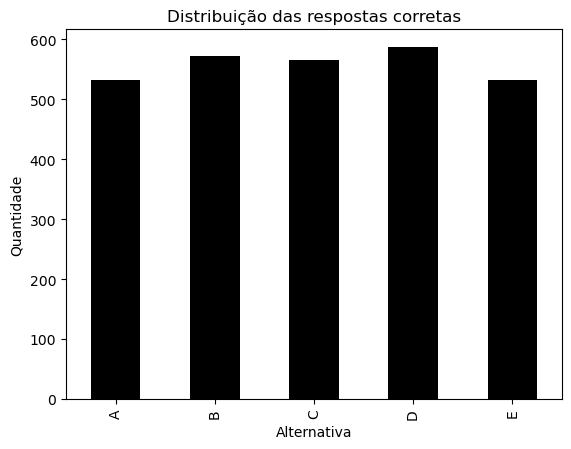

In [86]:
import matplotlib.pyplot as plt

ax = df['correctAlternative'].value_counts().sort_index().plot.bar(color="black")

ax.set_title('Distribuição das respostas corretas')
ax.set_xlabel('Alternativa')
ax.set_ylabel('Quantidade')

plt.xticks(range(5), ['A', 'B', 'C', 'D', 'E'])
plt.show()

Text(0.5, 1.0, 'Quantidade de questões de cada Disciplina')

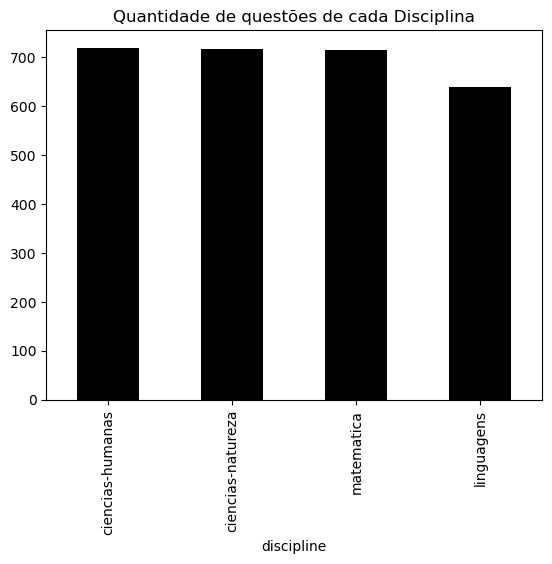

In [89]:

ax = df['correctAlternative'].value_counts().sort_index().plot.bar(color="black")

df['discipline'].value_counts().plot.bar(color='black')
ax.set_title('Quantidade de questões de cada Disciplina')


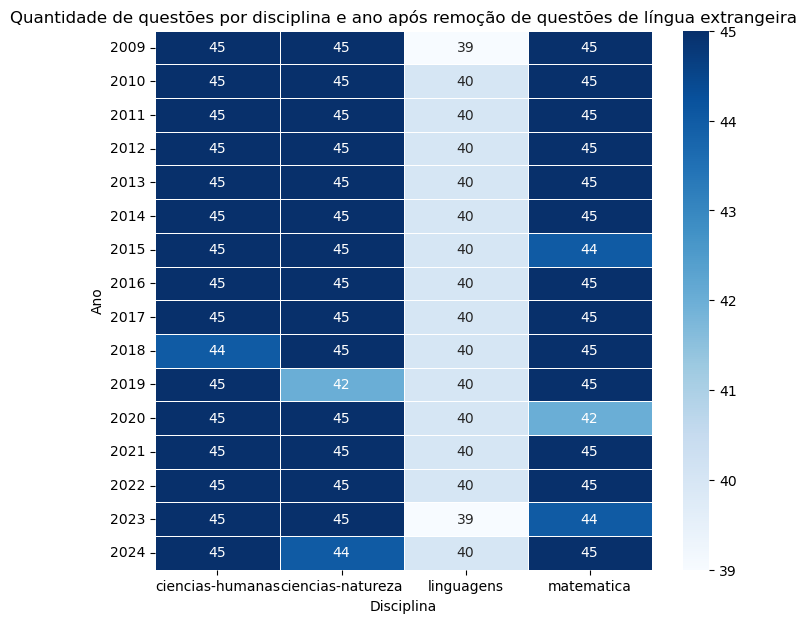

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

contagem = df.groupby(["year","discipline"]).size().unstack(fill_value=0)


plt.figure(figsize=(8,7))

sns.heatmap(
    contagem,
    annot=True,
    cmap="Blues",
    fmt="d",
    linewidths=.5
)

plt.title("Quantidade de questões por disciplina e ano após remoção de questões de língua extrangeira")
plt.xlabel("Disciplina")
plt.ylabel("Ano")
plt.show()

### Construção de uma lista de stopwords específicas para questões do ENEM

Além das remoções comuns de stopwords, para criar a WordCloud foram removidas algumas palavras que são comumente encontradas para referencias e guiar os alunos.

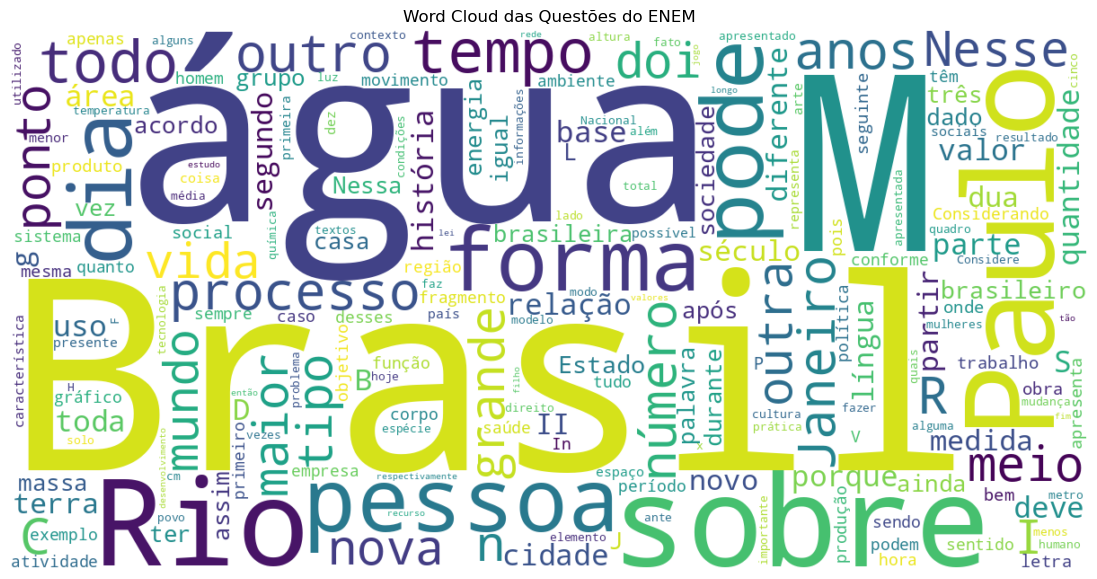

In [137]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

# Stopwords em português
stop_words = set(stopwords.words("portuguese"))

stop_words.update({
    "adaptado",
    "adaptada",
    "acesso",
    "disponível",
    "disponivel",
    "fonte",
    "acessado",
    "acessada",
    "www",
    "http",
    "https",
    "com",
    "br",
    "org",
    "gov",
    "ano",
    "figura",
    "imagem",
    "texto",
    "texto i",
    "texto ii",
    "cada",
    "desse",
    "dessa"
})

texto = " ".join(df["context"].dropna())

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stop_words,
    collocations=False,
).generate(texto)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud das Questões do ENEM")
plt.show()

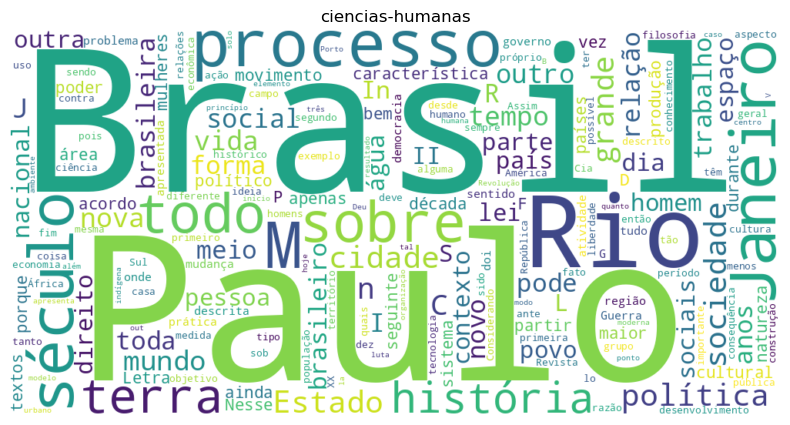

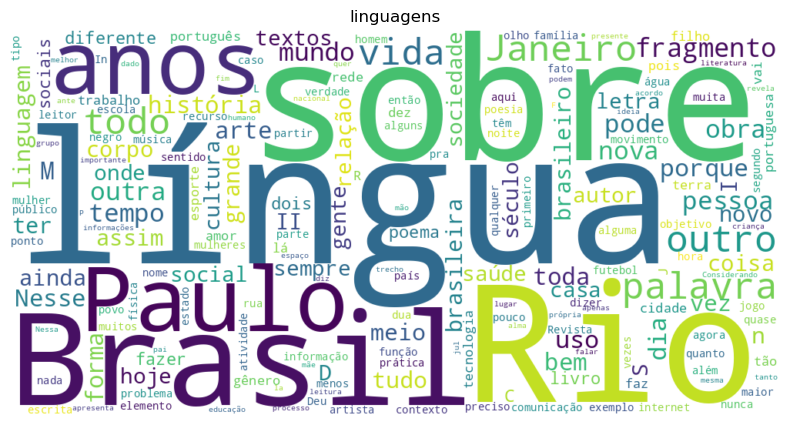

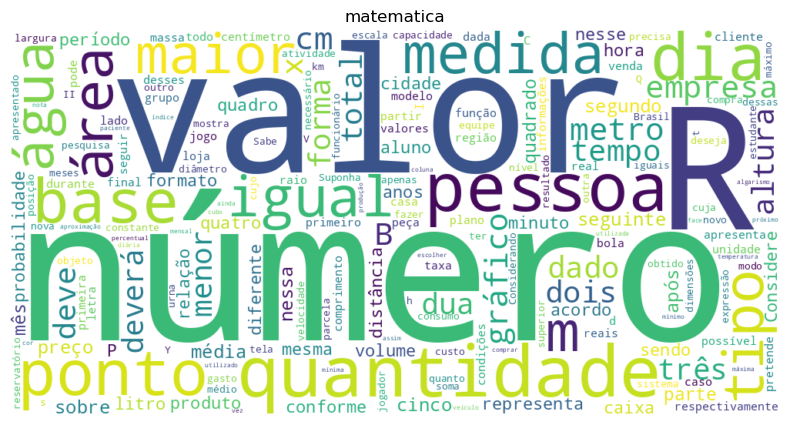

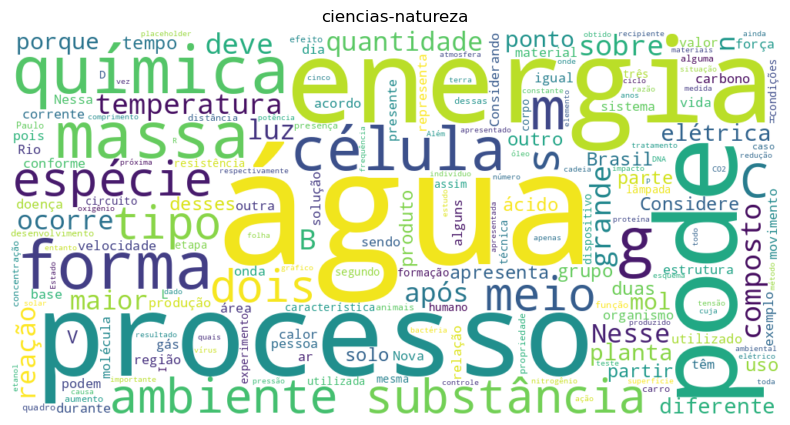

In [119]:
disciplinas = df["discipline"].unique()

for disc in disciplinas:
    texto = " ".join(
        df.loc[df["discipline"] == disc, "context"].dropna()
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        stopwords=stop_words,
        collocations=False,
    ).generate(texto)

    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(disc)
    plt.savefig(f"nuvem_{disc}.png")
    plt.show()

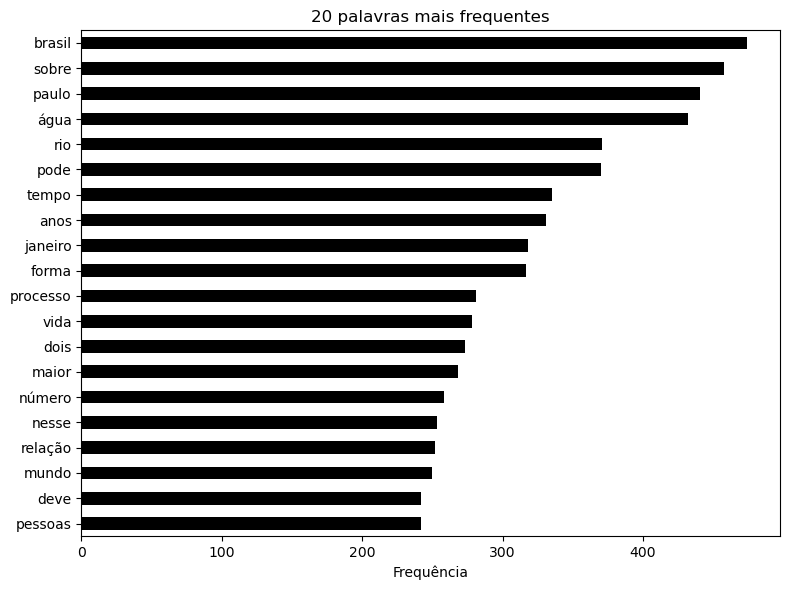

In [122]:
import re
from collections import Counter
from nltk.corpus import stopwords


texto = " ".join(df["context"].dropna()).lower()

# Remove URLs
texto = re.sub(r"http\S+|www\.\S+", " ", texto)

# Remove pontuação
texto = re.sub(r"[^\w\s]", " ", texto)

# Remove números
texto = re.sub(r"\d+", " ", texto)

palavras = [
    p for p in texto.split()
    if p not in stop_words and len(p) > 2
]

frequencia = Counter(palavras)

top20 = frequencia.most_common(20)


top20 = pd.DataFrame(top20, columns=["Palavra", "Frequência"])

top20.plot.barh(
    x="Palavra",
    y="Frequência",
    figsize=(8,6),
    legend=False, 
    color = 'black'
)

plt.title("20 palavras mais frequentes")
plt.xlabel("Frequência")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

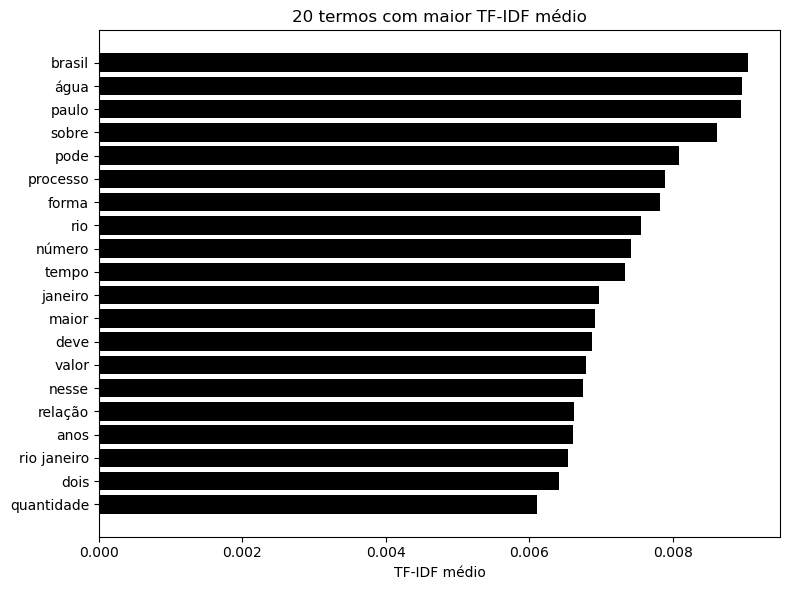

In [155]:
import pandas as pd

tfidf = model.named_steps["tfidf"]

X_tfidf = tfidf.transform(df["context"])

feature_names = tfidf.get_feature_names_out()

media = X_tfidf.mean(axis=0).A1

top20 = (
    pd.DataFrame({
        "Termo": feature_names,
        "TF-IDF": media
    })
    .sort_values("TF-IDF", ascending=False)
    .head(20)
)


plt.figure(figsize=(8,6))

plt.barh(top20["Termo"], top20["TF-IDF"], color='black')

plt.gca().invert_yaxis()

plt.title("20 termos com maior TF-IDF médio")
plt.xlabel("TF-IDF médio")

plt.tight_layout()
plt.show()

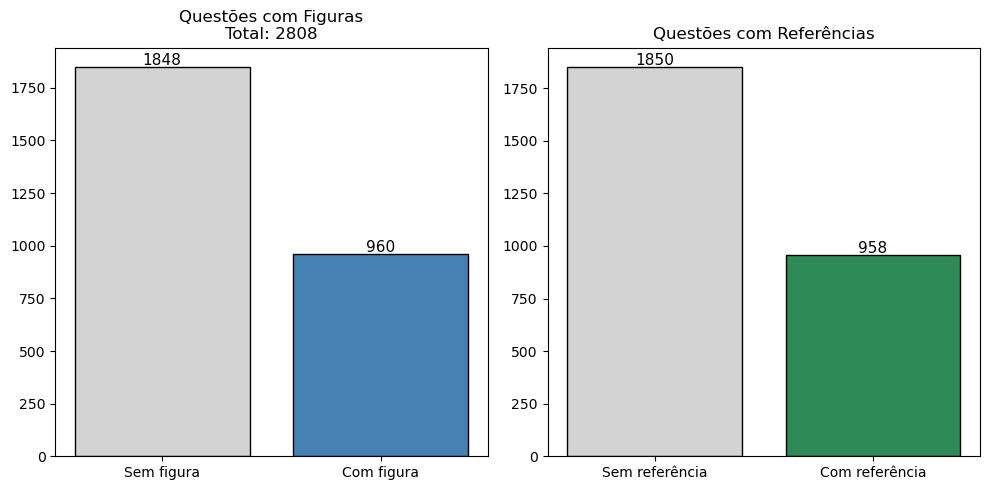

📊 Resumo:
  Total de questões: 2808
  Com figuras: 960 (34.2%)
  Com referências: 958 (34.1%)


In [33]:
# Criar colunas de análise
df['tem_figura'] = df['context'].str.contains(r'!\[.*?\]\(.*?\)', regex=True, na=False)
df['tem_referencia'] = df['context'].str.contains(r'[A-ZÀ-ÿ]+, [A-ZÀ-ÿ]\.', regex=True, na=False)

# Contagens
com_figura = df['tem_figura'].sum()
sem_figura = len(df) - com_figura
com_referencia = df['tem_referencia'].sum()

# Gráfico
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Figuras
axes[0].bar(['Sem figura', 'Com figura'], [sem_figura, com_figura], 
            color=['lightgray', 'steelblue'], edgecolor='black')
axes[0].set_title(f'Questões com Figuras\nTotal: {len(df)}')
for i, v in enumerate([sem_figura, com_figura]):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

# Referências
axes[1].bar(['Sem referência', 'Com referência'], 
            [len(df) - com_referencia, com_referencia], 
            color=['lightgray', 'seagreen'], edgecolor='black')
axes[1].set_title(f'Questões com Referências')
for i, v in enumerate([len(df) - com_referencia, com_referencia]):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"📊 Resumo:")
print(f"  Total de questões: {len(df)}")
print(f"  Com figuras: {com_figura} ({100*com_figura/len(df):.1f}%)")
print(f"  Com referências: {com_referencia} ({100*com_referencia/len(df):.1f}%)")

### Organizando Data Frame de trabalho

As questões vêm de fontes públicas diferentes cobrindo períodos distintos (2009–2023 e 2024 separadamente), com pequenas diferenças de schema. Em particular, o campo alternativesIntroduction (frase que antecede as alternativas) só existe em parte dos dados, por isso é incorporado ao context antes do merge, para não perder essa informação nas questões que a possuem.

In [55]:
import json

# Carregar 2009-2023
with open('questoes_enem_todas.json', 'r', encoding='utf-8') as f:
    questoes_2009_2023 = json.load(f)

# Juntar context + alternativesIntroduction nas anteriores|
for q in questoes_2009_2023:
    intro = q.get('alternativesIntroduction')
    ctx = q.get('context') or ''
    
    if intro:
        q['context'] = ctx + '\n' + intro
    q['alternativesIntroduction'] = None

# Carregar 2024
with open('2024.json', 'r', encoding='utf-8') as f:
    questoes_2024 = json.load(f)

# Juntar e salvar
todas = questoes_2009_2023 + questoes_2024

with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"✅ {len(todas)} questões salvas em enem_completo.json")

✅ 2937 questões salvas em enem_completo.json


==========================================================================================================

## Importação E treinamento de Modelo

### Atribuição de disciplina por posição

O ENEM não fornece a disciplina de cada questão diretamente — ela é inferida pela posição (index) dentro da prova, que segue uma ordem fixa por área. Essa ordem muda a partir da reforma de 2017 (mudança na sequência das áreas), por isso a regra abaixo é condicional ao ano. Questões de língua estrangeira (inglês/espanhol) são removidas separadamente por terem habilidades próprias, fora do escopo tratado aqui.

In [5]:
import pandas as pd

df = pd.read_json('enem_completo.json')

def atribuir_disciplina(index, year):

    if year <= 2016:
        if 1 <= index <= 45:
            return "ciencias-humanas"
        elif 46 <= index <= 90:
            return "ciencias-natureza"
        elif 91 <= index <= 135:
            return "linguagens"
        elif 136 <= index <= 180:
            return "matematica"

    else:
        if 1 <= index <= 45:
            return "linguagens"
        elif 46 <= index <= 90:
            return "ciencias-humanas"
        elif 91 <= index <= 135:
            return "ciencias-natureza"
        elif 136 <= index <= 180:
            return "matematica"

    return None


df["discipline"] = df.apply(
    lambda row: atribuir_disciplina(
        row["index"],
        row["year"]
    ),
    axis=1
)

print("Questões sem disciplina:",
      df["discipline"].isna().sum())

df.to_json(
    "enem_completo.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print(f"✅ Disciplinas atribuídas. Total: {len(df)} questões")

Questões sem disciplina: 0
✅ Disciplinas atribuídas. Total: 2937 questões


A partir daqui os dados estão limpos e organizados. A partir daqui serão aplicados os modelos de ML necessários.

Questões → Embeddings → Clusters → Rotular 1 questão por cluster → Propagar rótulos

In [6]:
def eh_lingua_estrangeira(index, year):

    if year <= 2016:
        # Linguagens está em 91–135
        return 131 <= index <= 135

    else:
        # Linguagens está em 1–45
        return 41 <= index <= 45

mask = (
    ((df["year"] <= 2016) &
     (df["index"].between(91,95)))
    |
    ((df["year"] >= 2017) &
     (df["index"].between(1,5)))
)

df = df[~mask].copy()

In [7]:
df[df['language'] == 'ingles']


,title,index,year,language,discipline,context,files,correctAlternative,alternativesIntroduction,alternatives


### Limpeza para uso no pipeline de classificação

Alguns ajustes aqui existem especificamente porque o texto será consumido por um LLM, não só analisado estatisticamente:

    A letra da alternativa correta (A–E) é trocada pelo texto completo da alternativa — uma letra isolada não carrega sinal semântico nenhum para o modelo.
    Links de imagem no context são substituídos pelo marcador [FIGURA], documentando que a questão depende de conteúdo visual que o pipeline não processa (em vez de deixar um link quebrado no meio do enunciado).
    Questões anuladas, sem resposta, ou com resposta-placeholder são descartadas — não têm um rótulo verdadeiro contra o qual classificar.


In [8]:
mapeamento = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
df['correctIndex'] = df['correctAlternative'].map(mapeamento)

def extrair_correta(alternativas):
    for alt in alternativas:
        if alt and alt.get('isCorrect'):
            return alt['text']
    return None

df['resposta_correta'] = df['alternatives'].apply(extrair_correta)

# Substituir links de imagens por [FIGURA]
df['context'] = df['context'].str.replace(
    r'!\[.*?\]\(https?://[^\s)]+\)', 
    '[FIGURA]', 
    regex=True
)


# Remover quebras de linha desnecessárias
df["context"] = df["context"].str.replace("\n", " ").str.replace("  ", " ")

    
# Lista de valores que você quer remover
valores_remover = ["Anulado", "Nulo", "Sem resposta", ""]

# Remove todos
df = df[~df["correctAlternative"].isin(valores_remover)]

In [9]:
df.drop(columns=['files','alternativesIntroduction', 'alternatives', 'correctAlternative', 'language', 'year', 'index','title'], inplace=True)

In [10]:
# Ver quantas têm placeholder
placeholders = df['resposta_correta'].str.contains('\[\[placeholder\]\]', regex=True, na=False)
print(f"Questões com placeholder: {placeholders.sum()}")

# Remover
df = df[~placeholders].copy()

Questões com placeholder: 5


## Teste dos modelos

#### 1. TF-IDF + Regressão Logística (baseline)

Antes de investir num pipeline de LLM para o problema real (~120 habilidades, poucos exemplos por classe), faz sentido testar um baseline leve e 100% local num problema mais fácil e com groundtruth confiável: prever discipline (só 4 classes, já conhecida via metadados). Se um modelo clássico já tiver dificuldade de generalizar nesse caso simples, é um sinal forte de que o problema de 120 classes — com amostras ainda menores e mais ruidosas por classe — não é resolvível de forma supervisionada clássica.



In [1]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

#===========================================================

from sklearn.metrics import classification_report


In [8]:
df["text"] = (
    "Questão: " + df["context"].astype(str).str.strip()
    + "\nResposta correta: " + df["resposta_correta"].astype(str).str.strip()
)

y = df['discipline']
X = df['text']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [29]:
from sklearn.model_selection import GridSearchCV

# Modelo base
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver='lbfgs',  # ← TROCAR para lbfgs
        max_iter=2000,
        random_state=42
    ))
])

# Grid com C ≤ 1 e foco em reduzir overfitting
param_grid = {
    # TF-IDF
    "tfidf__ngram_range": [(1,2), (1,3)],  # (1,1) é muito simples, (1,5) overfit
    "tfidf__min_df": [2, 3, 5],            # Remove palavras raras
    "tfidf__max_df": [0.85, 0.90, 0.92],   # Remove palavras muito comuns
    "tfidf__max_features": [2000, 3000, 4000, 5000],  # CRUCIAL!
    "tfidf__sublinear_tf": [True],          # Fixo (melhor para generalização)
    "tfidf__use_idf": [True, False],        # Testar com/sem IDF
    
    # Classificador (C ≤ 1)
    "clf__C": [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0],  # GRANULAR!
    "clf__class_weight": [None, 'balanced']  # Ajuda com classes desbalanceadas
    
}

# GridSearch com retorno de treino
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
    verbose=1  # Mostra progresso
)

print("Iniciando GridSearch...")
grid.fit(X_train, y_train)

# Resultados
print(f"\n✅ Melhor modelo encontrado:")
print(f"Params: {grid.best_params_}")
print(f"CV Score: {grid.best_score_:.3f}")

Iniciando GridSearch...
Fitting 5 folds for each of 2016 candidates, totalling 10080 fits

✅ Melhor modelo encontrado:
Params: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 4000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}
CV Score: 0.841


📊 RESULTADOS FINAIS
Train Accuracy: 0.9569
Test Accuracy:  0.8564
Gap:            0.1005

📋 CLASSIFICATION REPORT (Teste):
                   precision    recall  f1-score   support

 ciencias-humanas       0.77      0.78      0.78       144
ciencias-natureza       0.85      0.82      0.84       142
       linguagens       0.89      0.87      0.88       128
       matematica       0.92      0.95      0.93       143

         accuracy                           0.86       557
        macro avg       0.86      0.86      0.86       557
     weighted avg       0.86      0.86      0.86       557



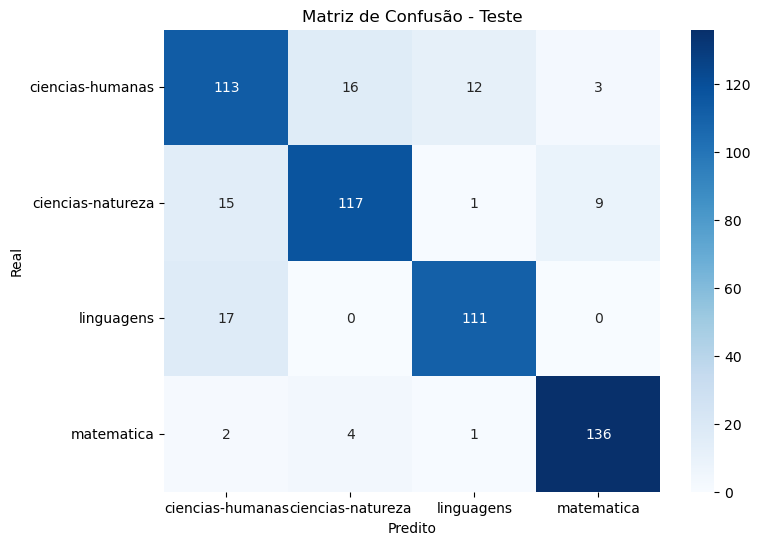


📈 PERFORMANCE POR CLASSE:
--------------------------------------------------
ciencias-humanas     | F1: 0.777 | P: 0.769 | R: 0.785 | N: 144.0
ciencias-natureza    | F1: 0.839 | P: 0.854 | R: 0.824 | N: 142.0
linguagens           | F1: 0.877 | P: 0.888 | R: 0.867 | N: 128.0
matematica           | F1: 0.935 | P: 0.919 | R: 0.951 | N: 143.0


In [30]:
# ============================================
# AVALIAÇÃO DO MELHOR MODELO
# ============================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Melhor modelo


# Previsões
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Métricas
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("="*60)
print("📊 RESULTADOS FINAIS")
print("="*60)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Gap:            {train_acc - test_acc:.4f}")

print("\n📋 CLASSIFICATION REPORT (Teste):")
print(classification_report(y_test, y_pred_test))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
classes = best_model.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Teste')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

# Análise por classe
print("\n📈 PERFORMANCE POR CLASSE:")
print("-" * 50)
f1_scores = classification_report(y_test, y_pred_test, output_dict=True)

for classe in classes:
    f1 = f1_scores[classe]['f1-score']
    precision = f1_scores[classe]['precision']
    recall = f1_scores[classe]['recall']
    support = f1_scores[classe]['support']
    
    print(f"{classe:20s} | F1: {f1:.3f} | P: {precision:.3f} | R: {recall:.3f} | N: {support}")

MODEL EVALUATION


,Metric,Value
0,Train Accuracy,0.956873
1,Test Accuracy,0.856373
2,Overfitting Gap,0.100500



Classification Report

                   precision    recall  f1-score   support

 ciencias-humanas       0.77      0.78      0.78       144
ciencias-natureza       0.85      0.82      0.84       142
       linguagens       0.89      0.87      0.88       128
       matematica       0.92      0.95      0.93       143

         accuracy                           0.86       557
        macro avg       0.86      0.86      0.86       557
     weighted avg       0.86      0.86      0.86       557



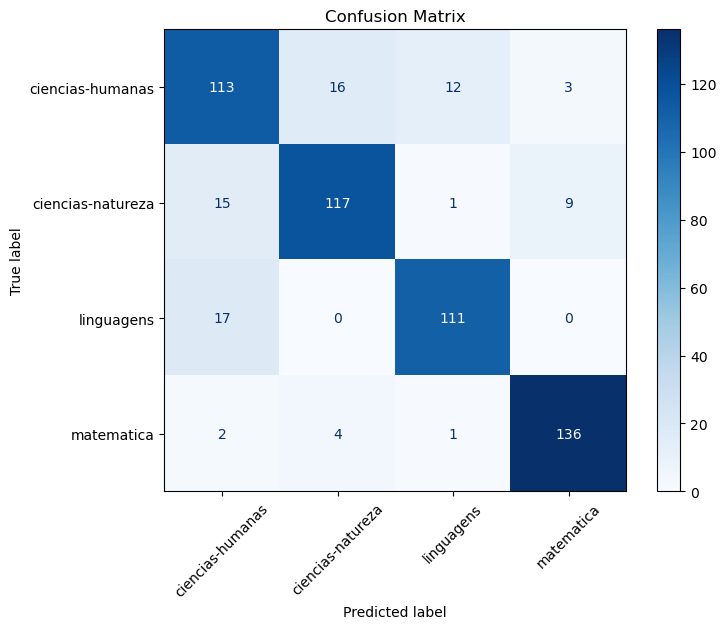

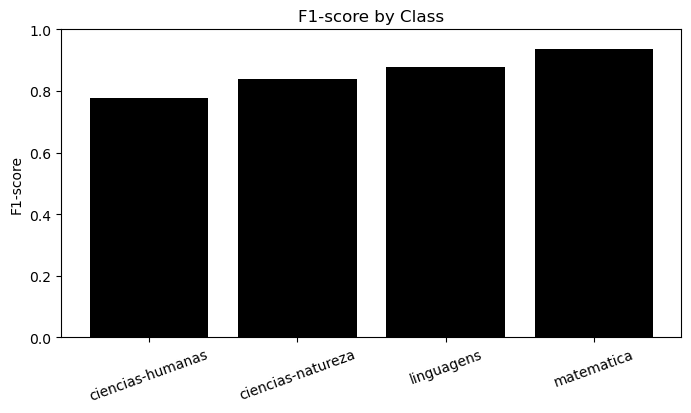


Cross Validation
Accuracy: 0.8437 ± 0.0055


,Evaluation,Accuracy
0,Train,0.956873
1,Test,0.856373
2,Cross Validation,0.843692


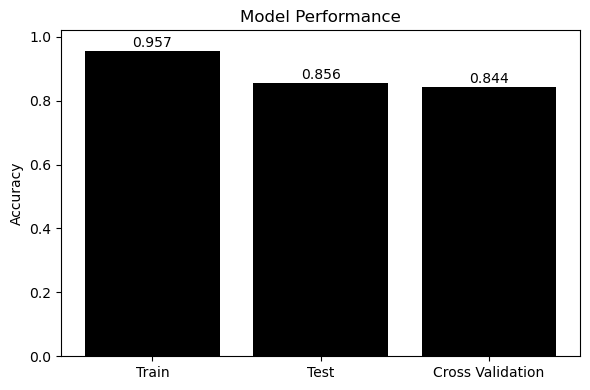


Best Parameters
{'clf__C': 1.0, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 4000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}

Best CV Score: 0.8405

Conclusion
• Holdout Accuracy : 0.8564
• Cross-validation : 0.8437 ± 0.0055
• Overfitting Gap  : 0.1005

Model presents moderate overfitting.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score


best_model = grid.best_estimator_
# ==========================================================
# MODEL EVALUATION
# ==========================================================

# Predictions
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
gap = train_acc - test_acc

print("="*70)
print("MODEL EVALUATION")
print("="*70)

summary = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Test Accuracy",
        "Overfitting Gap"
    ],
    "Value": [
        train_acc,
        test_acc,
        gap
    ]
})

display(summary)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_test))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

# ==========================================================
# F1 SCORE POR CLASSE
# ==========================================================

report = classification_report(
    y_test,
    y_pred_test,
    output_dict=True
)

classes = best_model.classes_

f1 = [
    report[c]["f1-score"]
    for c in classes
]

plt.figure(figsize=(8,4))

plt.bar(classes, f1, color='black')

plt.ylabel("F1-score")
plt.ylim(0,1)

plt.title("F1-score by Class")

plt.xticks(rotation=20)

plt.show()

# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\nCross Validation")
print(f"Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ==========================================================
# COMPARAÇÃO HOLDOUT x CROSS VALIDATION
# ==========================================================

comparison = pd.DataFrame({
    "Evaluation":[
        "Train",
        "Test",
        "Cross Validation"
    ],
    "Accuracy":[
        train_acc,
        test_acc,
        cv_scores.mean()
    ]
})

display(comparison)

plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison["Evaluation"],
    comparison["Accuracy"],
    color="black"
)

plt.ylim(0, 1.02)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("Accuracy")
plt.title("Model Performance")

plt.tight_layout()
plt.show()
# ==========================================================
# GRID SEARCH RESULT
# ==========================================================

print("\nBest Parameters")
print(grid.best_params_)

print(f"\nBest CV Score: {grid.best_score_:.4f}")

# ==========================================================
# CONCLUSION
# ==========================================================

print("\nConclusion")

print(f"• Holdout Accuracy : {test_acc:.4f}")
print(f"• Cross-validation : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• Overfitting Gap  : {gap:.4f}")

if gap < 0.08:
    print("\nModel presents good generalization.")
elif gap < 0.12:
    print("\nModel presents moderate overfitting.")
else:
    print("\nModel presents significant overfitting.")

### Leitura do resultado

Mesmo após tuning de hiperparâmetros via GridSearchCV, o melhor modelo manteve um gap perceptível entre treino e teste/validação cruzada — isso na tarefa mais fácil (4 classes balanceadas o suficiente). Esse resultado reforça a decisão de não tentar classificação supervisionada clássica diretamente nas 120 habilidades, e motiva a mudança para uma abordagem zero-shot baseada na descrição oficial de cada habilidade, na próxima seção.

#### Pipeline de classificação via LLM local

A partir daqui, a integração passa a ser feita com um modelo Ollama local, aplicada inicialmente a apenas uma parte dos dados por limitações de hardware. Principais decisões de design:

    Execução local (Ollama, gemma3:4b) — sem custo de API e sem enviar dados para fora, ao custo de rodar sobre uma amostra do dataset neste notebook, e não o conjunto completo.
    Saída estruturada via schema Pydantic (HabilidadeClassificacao), passada como format para o Ollama — garante JSON parseável em vez de texto livre, eliminando parsing frágil por regex.
    Restrição explícita à Matriz de Referência da área no prompt, para evitar que o modelo invente códigos de habilidade inexistentes.
    Campo habilidade_secundaria opcional — evita forçar uma decisão artificial de rótulo único quando duas habilidades são genuinamente centrais (raro, mas acontece).
    confianca e justificativa tornam a classificação auditável, não uma caixa-preta — importante para revisão manual posterior.
    Validação pós-hoc (resolver): qualquer código retornado que não exista na matriz da área vira um alerta para revisão, em vez de ser aceito silenciosamente.
    Checkpointing a cada CHECKPOINT_EVERY questões e retry com limite tornam o processamento resiliente a falhas em execuções longas de LLM local.
    Processamento sequencial por design: a maioria das instalações locais do Ollama atende uma geração por vez, então paralelizar sem OLLAMA_NUM_PARALLEL configurado só competiria por VRAM sem ganho real.


In [8]:
df = df.reset_index()
mr = pd.read_csv("matriz_de_referencia.csv")

In [10]:
df

,index,discipline,context,correctIndex,resposta_correta
0,0,ciencias-humanas,A atmosfera terrestre é composta pelos gases n...,2.0,"Reduzir o desmatamento, mantendo-se, assim, o ..."
1,1,ciencias-humanas,A fotossíntese é importante para a vida na Ter...,2.0,"A vida na Terra depende, em última análise, da..."
2,2,linguagens,[FIGURA] Tendo em vista a segunda fala do pers...,4.0,O principal objetivo do entrevistado é evidenc...
3,3,linguagens,Gênero dramático é aquele em que o artista usa...,2.0,O texto cênico pode originar-se dos mais varia...
4,4,linguagens,"Saúde, no modelo atual de qualidade de vida, é...",2.0,Pode desenvolver as atividades físicas do dia-...
...,...,...,...,...,...
2778,2931,matematica,A densidade demográfica de uma região é defini...,4.0,d de Q é igual a dois terços de d de R
2779,2932,matematica,"Atualmente, há telefones celulares com telas d...",3.0,"1,3."
2780,2933,matematica,Uma imobiliária iniciou uma campanha de divulg...,0.0,0Fevereiro.
2781,2934,matematica,"Um professor de desenho, apresentou uma peça d...",3.0,1 para 5.


## PARTE COM LLMs

In [1]:
import os
import pandas as pd
import ollama
from pydantic import BaseModel, Field, ValidationError
from tqdm import tqdm


In [2]:

df = pd.read_csv("ready_to_model.csv")

df["index"] = df["Unnamed: 0"]

df.drop(columns="Unnamed: 0", inplace = True )

In [3]:
MODEL = "qwen2.5:7b"        # troque pelo modelo que você tem puxado (`ollama list`)
NUM_CTX = 8192                # contexto — Ollama trunca silenciosamente se ficar baixo demais
CHECKPOINT_PATH = "checkpoint_habilidades.csv"
CHECKPOINT_EVERY = 25

COL_ID = "index"
COL_CONTEXT = "context"          # enunciado / contexto da questão
COL_RESPOSTA = "resposta_correta"
COL_TEXT = "text"                # coluna combinada, gerada por preparar_texto()
COL_DISCIPLINA = "discipline"

DISCIPLINA_TO_AREA = {
    "linguagens": "Linguagens, Códigos e suas Tecnologias",
    "matematica": "Matemática e suas Tecnologias",
    "ciencias-humanas": "Ciências Humanas e suas Tecnologias",
    "ciencias-natureza": "Ciências da Natureza e suas Tecnologias",
}

class HabilidadeClassificacao(BaseModel):
    raciocinio: str = Field(description="Comparação breve entre as habilidades candidatas, indicando se mais de uma é genuinamente central para resolver a questão")
    habilidade_principal: str = Field(description="Código da habilidade principal, ex: H05")
    habilidade_secundaria: str = Field(description="Código de uma segunda habilidade IGUALMENTE central pra resolver a questão. Use string vazia \"\" se não houver — deve ser a maioria dos casos")
    confianca: float = Field(ge=0.0, le=1.0, description="Confiança da classificação, de 0.0 a 1.0")
    justificativa: str = Field(description="Justificativa em no máximo 3 frases, cobrindo a habilidade principal e, se houver, a secundária")

PROMPT_TEMPLATE = """Você é um especialista na matriz de referência do Exame Nacional do Ensino Médio (ENEM).

Sua tarefa é identificar a habilidade da BNCC/Matriz do ENEM que melhor representa a competência exigida pela questão.

A classificação deve considerar principalmente a habilidade cognitiva exigida pela questão, e não apenas o tema abordado.

## Questão

{texto}

## Matriz de Referência ({area})

{matriz}

Execute obrigatoriamente as seguintes etapas:


1. Analise cuidadosamente o enunciado, os textos de apoio e as alternativas.

2. Identifique qual é a habilidade cognitiva central exigida para resolver corretamente a questão.

3. Analise individualmente cada habilidade disponível.

Para cada habilidade indique:

- Compatível
- Parcialmente compatível
- Incompatível

Explique brevemente o motivo.

4. Elimine todas as habilidades incompatíveis.

5. Entre as habilidades restantes, escolha apenas as TRÊS mais compatíveis.

Explique por que elas são superiores às demais.

6. Compare cuidadosamente essas três habilidades.

Explique as diferenças entre elas.

Justifique por que uma delas representa melhor a questão — essa é a habilidade_principal.

7. Verifique se, entre as três, existe uma segunda habilidade GENUINAMENTE tão central quanto a principal para resolver a questão (não apenas relacionada). Se sim, essa é a habilidade_secundaria. Isso deve ser raro — na dúvida, deixe habilidade_secundaria como string vazia "".

8. Informe um nível de confiança entre 0.0 e 1.0.

A confiança deve refletir sua certeza.

- 0.95–1.0 → praticamente sem dúvida
- 0.80–0.94 → forte evidência
- 0.60–0.79 → razoável
- abaixo de 0.60 → questão ambígua

9. Responda exclusivamente no formato JSON abaixo.

{{
    "raciocinio": "...",
    "habilidade_principal": "...",
    "habilidade_secundaria": "",
    "confianca": 0.0,
    "justificativa": "..."
}}

"""

In [4]:
def build_matriz_text(df_matriz: pd.DataFrame, area: str) -> str:
    subset = df_matriz[df_matriz["area"] == area]
    if subset.empty:
        raise ValueError(f"Nenhuma habilidade encontrada para area='{area}'. Verifique DISCIPLINA_TO_AREA.")
    return "\n".join(f"{r.habilidade_codigo}: {r.habilidade_descricao}" for r in subset.itertuples())


def preparar_texto(df: pd.DataFrame) -> pd.DataFrame:
    """Combina enunciado + resposta correta em um único bloco rotulado (coluna COL_TEXT).

    Mantém rastreio de linhas sem resposta preenchida em "sem_resposta" — isso é
    sinal de qualidade de dado que vale revisar à parte, em vez de deixar sumir
    silenciosamente dentro do texto combinado.
    """
    df = df.copy()
    df["sem_resposta"] = df[COL_RESPOSTA].isna() | (df[COL_RESPOSTA].astype(str).str.strip() == "")

    media_len = df[COL_RESPOSTA].astype(str).str.len().mean()
    if media_len < 5:
        print(
            f"[aviso] resposta_correta tem média de {media_len:.1f} caracteres — "
            f"pode ser só a letra (A-E) em vez do texto da alternativa. "
            f"Se for o caso, faça o join com o texto da alternativa antes de continuar."
        )

    df[COL_TEXT] = (
        "Questão: " + df[COL_CONTEXT].astype(str).str.strip()
        + "\nResposta correta: " + df[COL_RESPOSTA].astype(str).str.strip()
    )
    return df


def build_prompt(row: pd.Series, df_matriz: pd.DataFrame) -> str:
    area = DISCIPLINA_TO_AREA[row[COL_DISCIPLINA]]
    matriz_text = build_matriz_text(df_matriz, area)
    return PROMPT_TEMPLATE.format(
        area=area,
        matriz=matriz_text,
        texto=row[COL_TEXT],
    )

def classificar_questao(row: pd.Series, df_matriz: pd.DataFrame, max_retries: int = 3) -> dict:
    try:
        area = DISCIPLINA_TO_AREA[row[COL_DISCIPLINA]]
        matriz_area = df_matriz[df_matriz["area"] == area]
        prompt = build_prompt(row, df_matriz)
    except Exception as e:
        return {COL_ID: row[COL_ID], "erro": f"falha ao montar prompt: {e}"}

    for attempt in range(max_retries):
        try:
            resp = ollama.chat(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                format=HabilidadeClassificacao.model_json_schema(),
                options={"temperature": 0, "num_ctx": NUM_CTX},
            )
            parsed = HabilidadeClassificacao.model_validate_json(resp["message"]["content"])
            result = parsed.model_dump()
            result[COL_ID] = row[COL_ID]

            def resolver(codigo: str):
                if not codigo:
                    return None, None
                match = matriz_area[matriz_area["habilidade_codigo"] == codigo]
                if match.empty:
                    return None, f"código '{codigo}' não existe na área '{area}'"
                return match["habilidade_descricao"].iloc[0], None

            desc_p, alerta_p = resolver(parsed.habilidade_principal)
            desc_s, alerta_s = resolver(parsed.habilidade_secundaria)
            result["descricao_principal"] = desc_p
            result["descricao_secundaria"] = desc_s

            alertas = [a for a in (alerta_p, alerta_s) if a]
            if alertas:
                result["alerta"] = "; ".join(alertas) + " — revisar manualmente"

            return result
        except Exception as e:
            if attempt == max_retries - 1:
                return {COL_ID: row[COL_ID], "erro": str(e)}
            continue
    return {COL_ID: row[COL_ID], "erro": "esgotou tentativas"}





def rodar_pipeline(df_questoes: pd.DataFrame, df_matriz: pd.DataFrame) -> pd.DataFrame:
    if COL_TEXT not in df_questoes.columns:
        df_questoes = preparar_texto(df_questoes)

    ja_processados = set()
    resultados = []
    if os.path.exists(CHECKPOINT_PATH):
        checkpoint = pd.read_csv(CHECKPOINT_PATH)
        resultados = checkpoint.to_dict("records")
        ja_processados = set(checkpoint[COL_ID])
        print(f"Retomando checkpoint: {len(ja_processados)} questões já processadas.")

    pendentes = df_questoes[~df_questoes[COL_ID].isin(ja_processados)]

    # Sequencial de propósito: a maioria das instalações locais do Ollama processa
    # uma requisição de geração por vez (mesmo que aceite a conexão em paralelo),
    # então threads aqui só enfileiram sem ganho — e podem competir por VRAM.
    # Se você configurou OLLAMA_NUM_PARALLEL > 1 no servidor, pode paralelizar
    # com ThreadPoolExecutor como no script da API, mas teste antes.
    for i, (_, row) in enumerate(tqdm(pendentes.iterrows(), total=len(pendentes)), start=1):
        resultados.append(classificar_questao(row, df_matriz))
        if i % CHECKPOINT_EVERY == 0:
            pd.DataFrame(resultados).to_csv(CHECKPOINT_PATH, index=False)

    df_resultado = pd.DataFrame(resultados)
    df_resultado.to_csv(CHECKPOINT_PATH, index=False)
    return df_resultado


In [6]:
def build_matriz_text_rag(
    texto_questao: str,
    area: str,
    colecao_habilidades,
    modelo_embedding,
    n_results: int = 8
) -> str:
    """Versão com RAG: busca só as habilidades mais relevantes para a questão,
    em vez de listar todas as 30 da área.
    """
    embedding_questao = modelo_embedding.encode(texto_questao)

    resultados = colecao_habilidades.query(
        query_embeddings=[embedding_questao.tolist()],
        n_results=n_results,
        where={"area": area}
    )

    # Reconstrói o mesmo formato que build_matriz_text já produz:
    # "H1: descrição", uma por linha — assim o PROMPT_TEMPLATE não precisa mudar
    linhas = [
        f"{meta['habilidade_codigo']}: {doc}"
        for doc, meta in zip(resultados['documents'][0], resultados['metadatas'][0])
    ]
    return "\n".join(linhas)



def build_prompt_rag(
    row: pd.Series,
    colecao_habilidades,
    modelo_embedding,
    n_results: int = 8
) -> str:
    area = DISCIPLINA_TO_AREA[row[COL_DISCIPLINA]]
    matriz_text = build_matriz_text_rag(
        texto_questao=row[COL_TEXT],
        area=area,
        colecao_habilidades=colecao_habilidades,
        modelo_embedding=modelo_embedding,
        n_results=n_results
    )
    return PROMPT_TEMPLATE.format(
        area=area,
        matriz=matriz_text,
        texto=row[COL_TEXT],
    )

### Validação em amostra antes da execução completa

Antes de rodar o pipeline completo (custoso em tempo, por ser local e sequencial), uma amostra de 20 questões é processada isoladamente para validar o pipeline de ponta a ponta — taxas de erro e alerta servem como indicador rápido de saúde do pipeline antes do commit de tempo na execução completa sobre o dataset consolidado.

In [ ]:
CHECKPOINT_PATH = "checkpoint_teste.csv"   # separa do checkpoint do lote completo

df_questoes = df.copy()
df_matriz = mr.copy()

amostra = df_questoes.groupby("discipline", group_keys=False).apply(
    lambda x: x.sample(frac=0.08, random_state=0)  # ~8% de cada área, ajuste conforme o tempo disponível
)

df_resultado = rodar_pipeline(amostra, df_matriz)
df_final = amostra.merge(df_resultado, on=COL_ID, how="left")

erros = df_final[df_final["erro"].notna()] if "erro" in df_final.columns else pd.DataFrame()
alertas = df_final[df_final["alerta"].notna()] if "alerta" in df_final.columns else pd.DataFrame()
print(f"Concluído. {len(df_final)} questões, {len(erros)} com erro, {len(alertas)} com código fora da matriz.")

### Oficial

In [5]:
import os
import pandas as pd

CHECKPOINT_PATH = "checkpoint_teste.csv"

mr = pd.read_csv("matriz_de_referencia.csv")

df_questoes = df.copy()
df_matriz = mr.copy()

# --------------------------------------------------
# Carregar checkpoint
# --------------------------------------------------
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = pd.read_csv(CHECKPOINT_PATH)

    ids_processados = set(checkpoint[COL_ID])

    print(f"{len(ids_processados)} questões já classificadas.")

    # Remove as que já foram processadas
    df_questoes = df_questoes[
        ~df_questoes[COL_ID].isin(ids_processados)
    ]
else:
    checkpoint = pd.DataFrame()

print(f"Restam {len(df_questoes)} questões para classificar.")

# --------------------------------------------------
# Classificar somente as restantes
# --------------------------------------------------
df_resultado = rodar_pipeline(df_questoes, df_matriz)

df_final = df_questoes.merge(
    df_resultado,
    on=COL_ID,
    how="left"
)

# --------------------------------------------------
# Atualizar checkpoint
# --------------------------------------------------
checkpoint = pd.concat(
    [checkpoint, df_final],
    ignore_index=True
)

checkpoint.to_csv(CHECKPOINT_PATH, index=False)

print(f"Checkpoint atualizado: {len(checkpoint)} questões.")

2350 questões já classificadas.
Restam 433 questões para classificar.
Retomando checkpoint: 2350 questões já processadas.


100%|██████████| 433/433 [7:29:38<00:00, 62.31s/it]  


Checkpoint atualizado: 2783 questões.


### Conclusão e próximos passos

    Validar uma amostra dos rótulos gerados pelo LLM contra julgamento humano/especialista, para estimar acurácia real (não só taxa de erro técnico).
    Analisar a distribuição de confianca e a taxa de alerta para priorizar quais questões revisar manualmente primeiro.
    Tratar separadamente as questões marcadas com [FIGURA], já que dependem de conteúdo que o pipeline text-only não classifica de forma confiável.
    Escalar a execução para o dataset completo (~2900 questões) uma vez validada a qualidade na amostra.


In [20]:
amostra

,index,discipline,context,correctIndex,resposta_correta
2042,2155,ciencias-humanas,"Será que as coisas pareceriam diferentes se, d...",4.0,"Solipsismo, que reconhece limitações cognitiva..."
2573,2716,ciencias-humanas,Enormes alto-falantes sul-coreanos instalados ...,2.0,Divergências político-ideológicas de agentes e...
975,1019,ciencias-humanas,A Comissão Nacional da Verdade (CNV) reuniu re...,4.0,Esclarecer as circunstâncias de violações aos ...
591,615,ciencias-humanas,[FIGURA] Disponível em: www.metmuseum.org. Ace...,4.0,Expansionismo – diversidade dos territórios co...
1910,2013,ciencias-humanas,"A fome não é um problema técnico, pois ela não...",1.0,Padrão de distribuição de renda.
...,...,...,...,...,...
937,981,matematica,"O volume real do armário, em centímetros cúbi...",4.0,6 000 000.
1127,1181,matematica,[FIGURA] A ordem de classificação final desse ...,1.0,"B, A, C, E, D."
398,413,matematica,Para uma atividade realizada no laboratório de...,2.0,"11,2 e 4,8"
1456,1532,matematica,A água para o abastecimento de um prédio é arm...,3.0,None


#### Amostra de 8% com o primeiro LLM

Nessa primeira experimentação observei que o modelo estava cometendo algumas confusões simples, Então testei um modelo mais poderoso. O que acabou sendo muito lento por limitações computacionais. Porém os resultados desse novo modelo parecem ser mais acertivos. Então decidi aqui utilizar um processo de ps

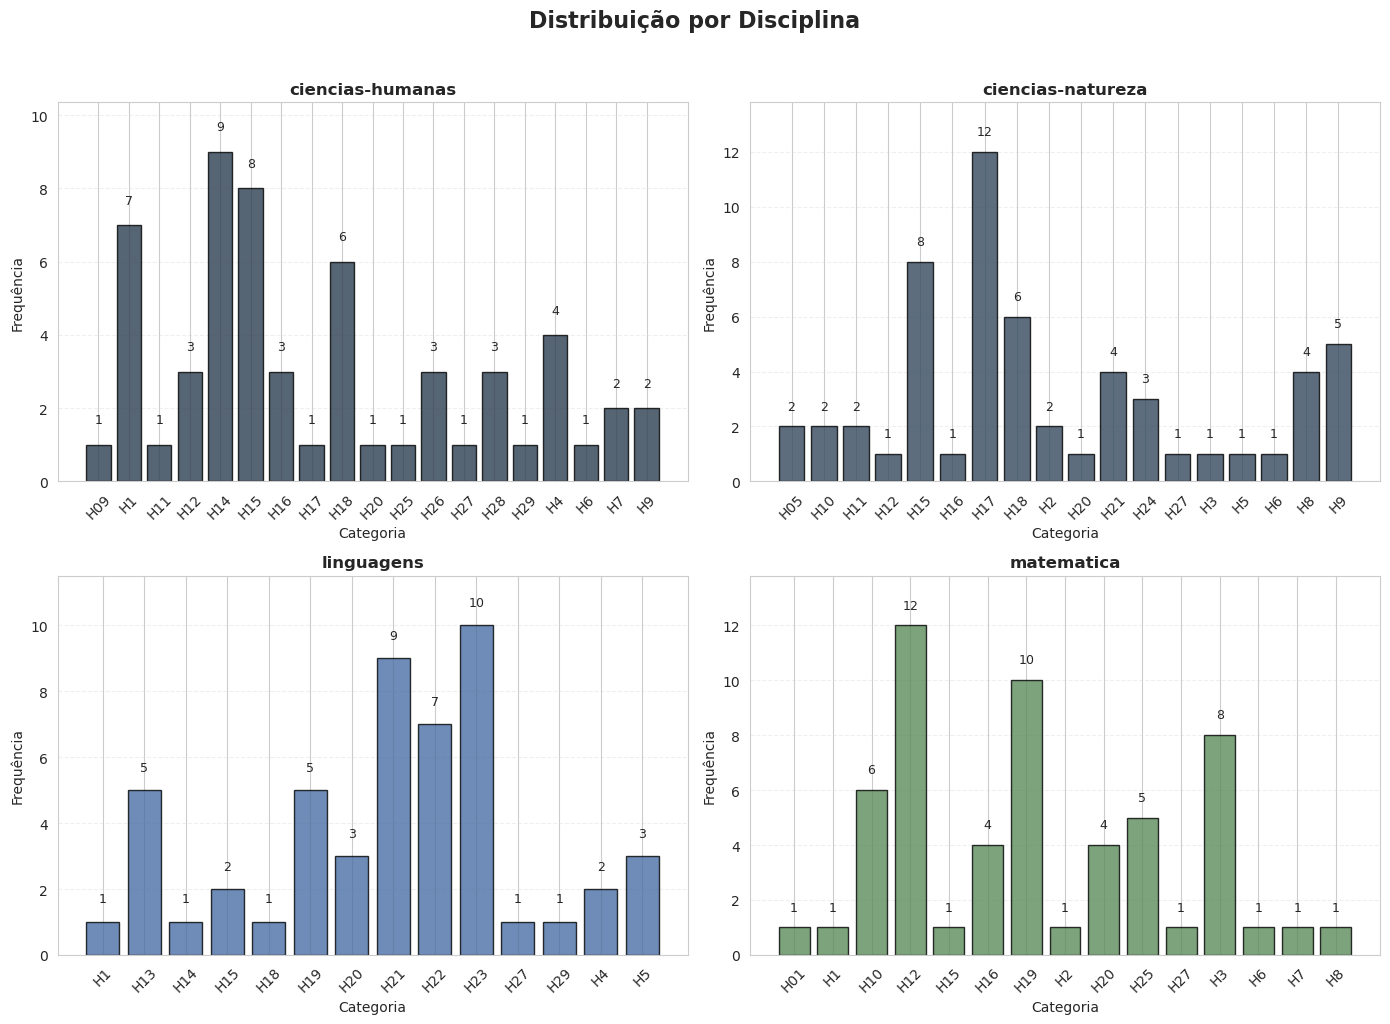

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# PLOTAR DISTRIBUIÇÃO POR DISCIPLINA - 2x2 COM ESTILO
# ============================================

# Definir coluna que você quer plotar
coluna_plot = 'habilidade_principal'  # ← MUDE AQUI!

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 10

# Obter disciplinas
disciplinas = sorted(set(df['discipline']))

# Criar subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Cores diferentes para cada disciplina
cores = ['#2c3e50', '#34495e', '#4a6fa5', '#5b8c5a']
cores = cores[:len(disciplinas)]

# Plotar cada disciplina
for i, (disciplina, cor) in enumerate(zip(disciplinas, cores)):
    # Filtrar dados
    dados_disciplina = df_final[df_final['discipline'] == disciplina]
    
    # Contar valores
    contagens = dados_disciplina[coluna_plot].value_counts().sort_index()
    
    # Plotar barras
    bars = axes[i].bar(
        contagens.index.astype(str),
        contagens.values,
        color=cor,
        alpha=0.8,
        edgecolor='black',
        linewidth=1
    )
    
    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.5,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    
    # Configurações
    axes[i].set_title(f'{disciplina}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Categoria', fontsize=10)
    axes[i].set_ylabel('Frequência', fontsize=10)
    axes[i].grid(True, alpha=0.3, linestyle='--', axis='y')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Ajustar limite do eixo y para acomodar os valores
    axes[i].set_ylim(0, contagens.max() * 1.15)

# Remover subplots vazios
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Título geral
fig.suptitle('Distribuição por Disciplina', fontsize=16, fontweight='bold', y=1.02)

# Ajustar layout
plt.tight_layout()
plt.show()

In [78]:
import pandas as pd
df_ready_to_model = pd.read_csv("ready_to_model.csv")
df_final = pd.read_csv("checkpoint_teste.csv")

df = pd.merge(df_final, df_ready_to_model, left_on='index', right_on='Unnamed: 0', how='left')

In [89]:
df = df_ready_to_model.copy()

In [13]:
df["discipline"].unique()



array(['ciencias-humanas', 'linguagens', 'matematica',
       'ciencias-natureza'], dtype=object)

In [ ]:
df = pd.read_csv("checkpoint_teste.csv")

df.drop(df[df["discipline"].isna()].index, inplace=True)

df.to_csv("checkpoint_teste.csv", index=False)

## Versão com RAG

In [16]:
import pandas as pd

mr = pd.read_csv("matriz_de_referencia.csv")


# Gerar embeddings para todas as habilidades da Matriz de Referência
# Decisão: usar habilidade_descricao sozinha, ou combinar com competencia_descricao?
# Por ora, vamos de habilidade_descricao pura — é o nível de granularidade que
# efetivamente diferencia uma habilidade da outra dentro da mesma competência.
from sentence_transformers import SentenceTransformer

modelo_embedding = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')



textos_habilidades = mr['habilidade_descricao'].tolist()
codigos_habilidades = mr['habilidade_codigo'].tolist()

# encode() aceita uma lista inteira de uma vez (processamento em lote é mais
# eficiente que rodar .encode() em loop, célula a célula)
embeddings_habilidades = modelo_embedding.encode(
    textos_habilidades,
    show_progress_bar=True,
    batch_size=32
)

print(f"Total de habilidades processadas: {len(textos_habilidades)}")
print(f"Formato da matriz de embeddings: {embeddings_habilidades.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Total de habilidades processadas: 120
Formato da matriz de embeddings: (120, 384)


In [ ]:
df['area'] = df['disciplina'].map(DISCIPLINA_TO_AREA)

In [13]:
import chromadb

# Cliente persistente: os dados ficam salvos em disco, não se perdem
# ao reiniciar o kernel do notebook
cliente_chroma = chromadb.PersistentClient(path="./chroma_enem_db")

# Cria (ou recupera, se já existir) a coleção onde as 120 habilidades
# vão ficar indexadas
colecao_habilidades = cliente_chroma.get_or_create_collection(
    name="matriz_referencia_enem"
)

In [14]:
# Preparando os metadados de cada habilidade — isso é o que permite
# filtrar por área depois, além de recuperar informação extra sem
# precisar consultar o DataFrame original de novo
metadados = mr.apply(
    lambda linha: {
        "area": linha["area"],
        "competencia_numero": int(linha["competencia_numero"]),
        "competencia_descricao": linha["competencia_descricao"],
        "habilidade_codigo": linha["habilidade_codigo"]
    },
    axis=1
).tolist()

# Prefixo curto e único por área, definido explicitamente
# (evita colisão que aconteceria cortando caracteres, já que
# "Ciências Humanas" e "Ciências da Natureza" começam igual)
AREA_TO_PREFIXO = {
    'Linguagens, Códigos e suas Tecnologias': 'LC',
    'Matemática e suas Tecnologias': 'MT',
    'Ciências Humanas e suas Tecnologias': 'CH',
    'Ciências da Natureza e suas Tecnologias': 'CN'
}

ids_habilidades = (
    df_matriz['area'].map(AREA_TO_PREFIXO) + "_" + df_matriz['habilidade_codigo']
).tolist()

print(ids_habilidades[:5])
print(len(ids_habilidades), "IDs gerados")
print(len(set(ids_habilidades)), "IDs únicos")

['LC_H1', 'LC_H2', 'LC_H3', 'LC_H4', 'LC_H5']
120 IDs gerados
120 IDs únicos


In [17]:



colecao_habilidades.add(
    ids=ids_habilidades,
    embeddings=embeddings_habilidades.tolist(),
    documents=textos_habilidades,
    metadatas=metadados
)

print(f"Habilidades indexadas no Chroma: {colecao_habilidades.count()}")

Habilidades indexadas no Chroma: 120


In [49]:
# Testando a busca: uma questão de exemplo do dataset
questao_teste = df['context'].iloc[0]  # ajuste o nome da coluna conforme seu df real
area_teste = df['area'].iloc[0]

print("Questão:", questao_teste[:200], "...")
print("Área:", area_teste)

# Gera o embedding da questão na hora
embedding_questao = modelo_embedding.encode(questao_teste)

# Busca as habilidades mais similares, filtrando pela área da questão
resultados = colecao_habilidades.query(
    query_embeddings=[embedding_questao.tolist()],
    n_results=5,
    where={"area": area_teste}
)

for i, (doc, meta, dist) in enumerate(zip(
    resultados['documents'][0],
    resultados['metadatas'][0],
    resultados['distances'][0]
)):
    print(f"\n{i+1}. [{meta['habilidade_codigo']}] (distância: {dist:.4f})")
    print(f"   {doc[:150]}...")

Questão: A atmosfera terrestre é composta pelos gases nitrogênio (N2) e oxigênio (O2), que somam cerca de 99%, e por gases traços, entre eles o gás carbônico (CO2), vapor de água (H2O), metano (CH4), ozônio (O ...
Área: Ciências Humanas e suas Tecnologias

1. [H30] (distância: 0.6490)
   Avaliar as relações entre preservação e degradação da vida no planeta nas diferentes escalas....

2. [H26] (distância: 0.7621)
   Identificar em fontes diversas o processo de ocupação dos meios físicos e as relações da vida humana com a paisagem....

3. [H29] (distância: 0.7984)
   Reconhecer a função dos recursos naturais na produção do espaço geográfico, relacionando-os com as mudanças provocadas pelas ações humanas....

4. [H28] (distância: 0.8984)
   Relacionar o uso das tecnologias com os impactos sócio-ambientais em diferentes contextos histórico-geográficos....

5. [H8] (distância: 0.9219)
   Analisar a ação dos estados nacionais no que se refere à dinâmica dos fluxos populacionais e no enfrenta

In [9]:
df['area'] = df['discipline'].map(DISCIPLINA_TO_AREA)

df

,discipline,context,correctIndex,resposta_correta,index,area
0,ciencias-humanas,A atmosfera terrestre é composta pelos gases n...,2.0,"Reduzir o desmatamento, mantendo-se, assim, o ...",0,Ciências Humanas e suas Tecnologias
1,ciencias-humanas,A fotossíntese é importante para a vida na Ter...,2.0,"A vida na Terra depende, em última análise, da...",1,Ciências Humanas e suas Tecnologias
2,linguagens,[FIGURA] Tendo em vista a segunda fala do pers...,4.0,O principal objetivo do entrevistado é evidenc...,2,"Linguagens, Códigos e suas Tecnologias"
3,linguagens,Gênero dramático é aquele em que o artista usa...,2.0,O texto cênico pode originar-se dos mais varia...,3,"Linguagens, Códigos e suas Tecnologias"
4,linguagens,"Saúde, no modelo atual de qualidade de vida, é...",2.0,Pode desenvolver as atividades físicas do dia-...,4,"Linguagens, Códigos e suas Tecnologias"
...,...,...,...,...,...,...
2778,matematica,A densidade demográfica de uma região é defini...,4.0,d de Q é igual a dois terços de d de R,2931,Matemática e suas Tecnologias
2779,matematica,"Atualmente, há telefones celulares com telas d...",3.0,"1,3.",2932,Matemática e suas Tecnologias
2780,matematica,Uma imobiliária iniciou uma campanha de divulg...,0.0,0Fevereiro.,2933,Matemática e suas Tecnologias
2781,matematica,"Um professor de desenho, apresentou uma peça d...",3.0,1 para 5.,2934,Matemática e suas Tecnologias


In [7]:
def classificar_questao_rag(
    row: pd.Series,
    df_matriz: pd.DataFrame,
    colecao_habilidades,
    modelo_embedding,
    n_results: int = 8,
    max_retries: int = 3
) -> dict:
    try:
        area = DISCIPLINA_TO_AREA[row[COL_DISCIPLINA]]
        matriz_area = df_matriz[df_matriz["area"] == area]  # continua as 30, só para validação
        prompt = build_prompt_rag(
            row=row,
            colecao_habilidades=colecao_habilidades,
            modelo_embedding=modelo_embedding,
            n_results=n_results
        )
    except Exception as e:
        return {COL_ID: row[COL_ID], "erro": f"falha ao montar prompt: {e}"}

    for attempt in range(max_retries):
        try:
            resp = ollama.chat(
                model=MODEL,
                messages=[{"role": "user", "content": prompt}],
                format=HabilidadeClassificacao.model_json_schema(),
                options={"temperature": 0, "num_ctx": NUM_CTX},
            )
            parsed = HabilidadeClassificacao.model_validate_json(resp["message"]["content"])
            result = parsed.model_dump()
            result[COL_ID] = row[COL_ID]

            def resolver(codigo: str):
                if not codigo:
                    return None, None
                match = matriz_area[matriz_area["habilidade_codigo"] == codigo]
                if match.empty:
                    return None, f"código '{codigo}' não existe na área '{area}'"
                return match["habilidade_descricao"].iloc[0], None

            desc_p, alerta_p = resolver(parsed.habilidade_principal)
            desc_s, alerta_s = resolver(parsed.habilidade_secundaria)
            result["descricao_principal"] = desc_p
            result["descricao_secundaria"] = desc_s

            alertas = [a for a in (alerta_p, alerta_s) if a]
            if alertas:
                result["alerta"] = "; ".join(alertas) + " — revisar manualmente"

            return result
        except Exception as e:
            if attempt == max_retries - 1:
                return {COL_ID: row[COL_ID], "erro": str(e)}
            continue
    return {COL_ID: row[COL_ID], "erro": "esgotou tentativas"}

In [10]:
# Amostra estratificada: 10 questões de cada área, com seed fixa para reprodutibilidade
amostra_teste = (
    df_questoes
    .groupby(COL_DISCIPLINA, group_keys=False)[df_questoes.columns.tolist()]
    .apply(lambda grupo: grupo.sample(n=50, random_state=42), include_groups=False)
    .reset_index(drop=True)
)

# Garante que a coluna de texto combinado já existe antes de rodar o pipeline
if COL_TEXT not in amostra_teste.columns:
    amostra_teste = preparar_texto(amostra_teste)

print(amostra_teste[COL_DISCIPLINA].value_counts())
print(f"Total: {len(amostra_teste)} questões")


def rodar_pipeline_rag(
    df_questoes: pd.DataFrame,
    df_matriz: pd.DataFrame,
    colecao_habilidades,
    modelo_embedding,
    n_results: int = 8,
    checkpoint_path: str = "checkpoint_rag_teste.csv"
) -> pd.DataFrame:
    if COL_TEXT not in df_questoes.columns:
        df_questoes = preparar_texto(df_questoes)

    resultados = []
    for _, row in tqdm(df_questoes.iterrows(), total=len(df_questoes)):
        resultados.append(
            classificar_questao_rag(
                row=row,
                df_matriz=df_matriz,
                colecao_habilidades=colecao_habilidades,
                modelo_embedding=modelo_embedding,
                n_results=n_results
            )
        )

    df_resultado = pd.DataFrame(resultados)
    df_resultado.to_csv(checkpoint_path, index=False)
    return df_resultado

discipline
ciencias-humanas     50
ciencias-natureza    50
linguagens           50
matematica           50
Name: count, dtype: int64
Total: 200 questões


In [18]:
df_resultado_rag = rodar_pipeline_rag(
    df_questoes=amostra_teste,
    df_matriz=df_matriz,
    colecao_habilidades=colecao_habilidades,
    modelo_embedding=modelo_embedding,
    n_results=8
)

df_resultado_rag.head()

100%|██████████| 200/200 [2:34:11<00:00, 46.26s/it]  


,raciocinio,habilidade_principal,habilidade_secundaria,confianca,justificativa,index,descricao_principal,descricao_secundaria,alerta
0,A questão apresenta um texto que descreve uma ...,H18: Analisar diferentes processos de produção...,,0.95,A habilidade H18 é a mais adequada porque a qu...,2722,None,None,código 'H18: Analisar diferentes processos de ...
1,A questão exige que o aluno identifique a prin...,H1: Interpretar historicamente e/ou geografica...,,0.95,A habilidade H1 é a mais adequada porque exige...,2814,None,None,código 'H1: Interpretar historicamente e/ou ge...
2,A questão exige que o aluno identifique a rela...,H1: Interpretar historicamente e/ou geografica...,,0.95,"A habilidade principal, H1, é a mais adequada ...",2523,None,None,código 'H1: Interpretar historicamente e/ou ge...
3,A questão exige analisar o conceito de tempo l...,H18: Analisar diferentes processos de produção...,,0.95,A habilidade H18 é a mais central porque envol...,2708,None,None,código 'H18: Analisar diferentes processos de ...
4,A questão apresenta um texto que descreve a fo...,H29: Reconhecer a função dos recursos naturais...,,0.95,A habilidade H29 é central porque a questão ex...,2548,None,None,código 'H29: Reconhecer a função dos recursos ...


In [ ]:

# Apenas nas linhas em que a descrição está vazia
mask = df_resultado["descricao_principal"].isna() | (df_resultado["descricao_principal"].str.strip() == "")

# Divide apenas na primeira ocorrência de ":"
separado = df_resultado.loc[mask, "habilidade_principal"].str.split(" - ", n=1, expand=True)

# Atualiza as colunas
df_resultado.loc[mask, "habilidade_principal"] = separado[0].str.strip()
df_resultado.loc[mask, "descricao_principal"] = separado[1].str.strip()









# Apenas nas linhas em que a descrição está vazia
mask = df_resultado_rag["descricao_principal"].isna() | (df_resultado_rag["descricao_principal"].str.strip() == "")

# Divide apenas na primeira ocorrência de ":"
separado = df_resultado_rag.loc[mask, "habilidade_principal"].str.split(" - ", n=1, expand=True)

# Atualiza as colunas
df_resultado_rag.loc[mask, "habilidade_principal"] = separado[0].str.strip()
df_resultado_rag.loc[mask, "descricao_principal"] = separado[1].str.strip()

In [ ]:
# Quantas linhas entraram na máscara?
print(mask.sum())

In [ ]:

df_resultado_rag.head(4)

## Após concluidas as duas análises. Uma amostra Com RAG e outra sem RAG, abaixo estão alguns graficos gerados para representar esses resultados

/home/artur/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


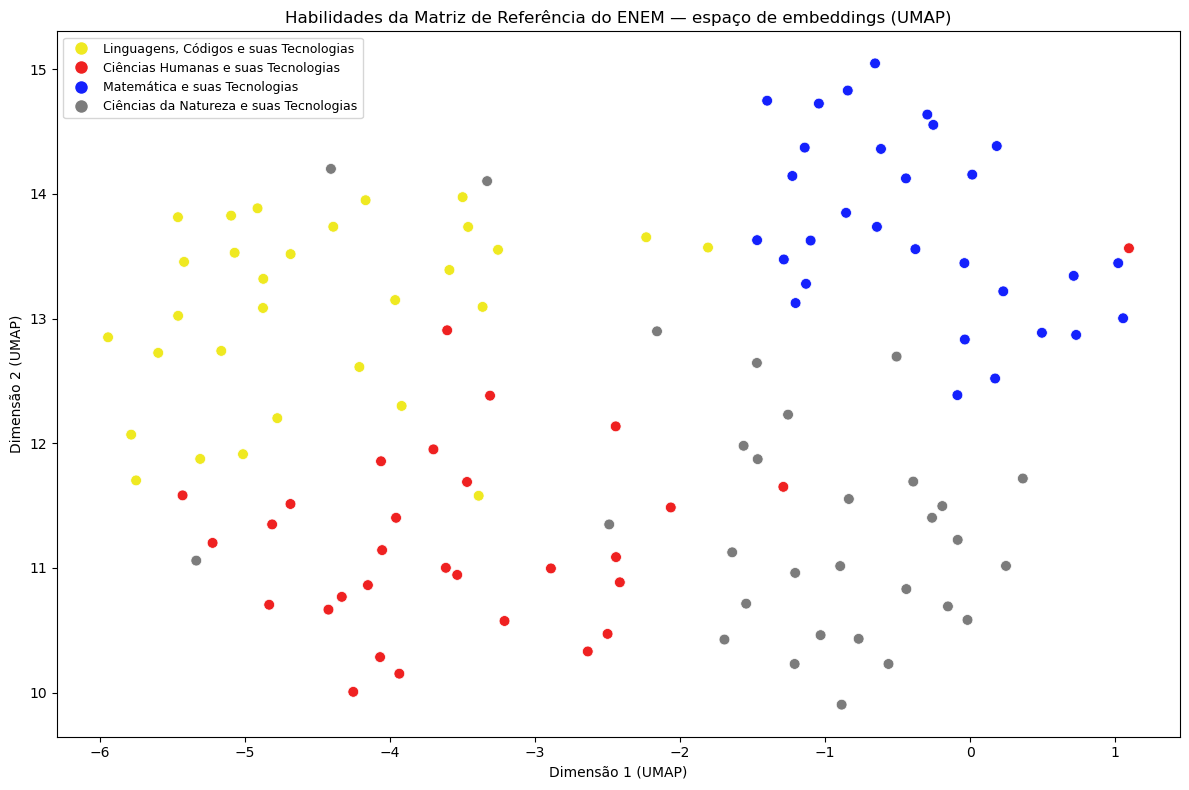

In [53]:
import umap
import matplotlib.pyplot as plt

# Reduz de 384 dimensões para 2, preservando a estrutura de vizinhança local
reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_habilidades)

# Cores por área — reaproveitando a mesma lógica de categorização do projeto
cores_area = {
    'Linguagens, Códigos e suas Tecnologias': '#efe921',
    'Ciências Humanas e suas Tecnologias': '#ef2121',
    'Matemática e suas Tecnologias': '#1421fd',
    'Ciências da Natureza e suas Tecnologias': '#7c7c7c'
}
cores_pontos = df_matriz['area'].map(cores_area)

plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cores_pontos, s=60, alpha=1, edgecolors='white', linewidths=0.5)

# Legenda manual (já que estamos usando cores mapeadas, não plot direto por grupo)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cor, markersize=10, label=area)
           for area, cor in cores_area.items()]
plt.legend(handles=handles, loc='best', fontsize=9)

plt.title('Habilidades da Matriz de Referência do ENEM — espaço de embeddings (UMAP)')
plt.xlabel('Dimensão 1 (UMAP)')
plt.ylabel('Dimensão 2 (UMAP)')
plt.tight_layout()
plt.savefig('embeddings_matriz_enem.png', dpi=150)
plt.show()

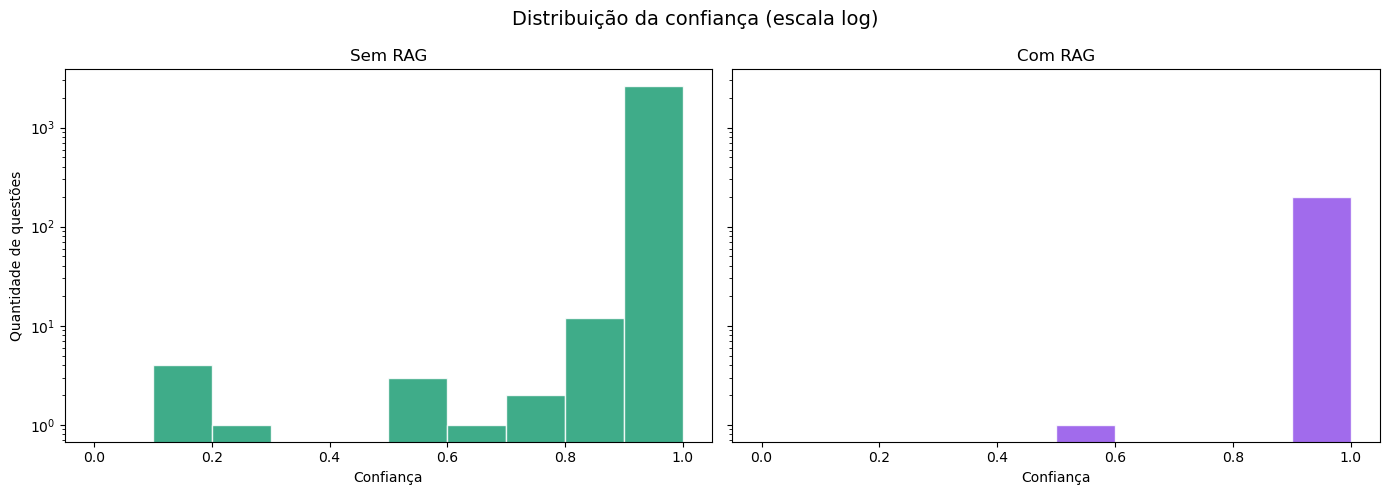

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Sem RAG
ax[0].hist(
    df_resultado['confianca'],
    bins=10,
    range=(0, 1),
    color='#1D9E75',
    edgecolor='white',
    alpha=0.85
)
ax[0].set_yscale('log')
ax[0].set_title('Sem RAG')
ax[0].set_xlabel('Confiança')
ax[0].set_ylabel('Quantidade de questões')

# Com RAG
ax[1].hist(
    df_resultado_rag['confianca'],
    bins=10,
    range=(0, 1),
    color='#9151e9',
    edgecolor='white',
    alpha=0.85
)
ax[1].set_yscale('log')
ax[1].set_title('Com RAG')
ax[1].set_xlabel('Confiança')

fig.suptitle('Distribuição da confiança (escala log)', fontsize=14)

plt.tight_layout()
plt.show()

In [75]:
# Criar um mapeamento index -> disciplina
mapa_disciplina = df.set_index("index")["discipline"]

# Adicionar a disciplina aos resultados
df_resultado["discipline"] = df_resultado["index"].map(mapa_disciplina)
df_resultado_rag["discipline"] = df_resultado_rag["index"].map(mapa_disciplina)

In [88]:
df_resultado = df_resultado[df_resultado["habilidade_principal"] != "Incompatível"]

In [90]:
# Índices das questões que passaram pelo RAG
indices_rag = df_resultado_rag["index"].unique()

# DataFrame contendo apenas essas questões,
# mas com a classificação final
df_rag = df_resultado[df_resultado["index"].isin(indices_rag)].copy()

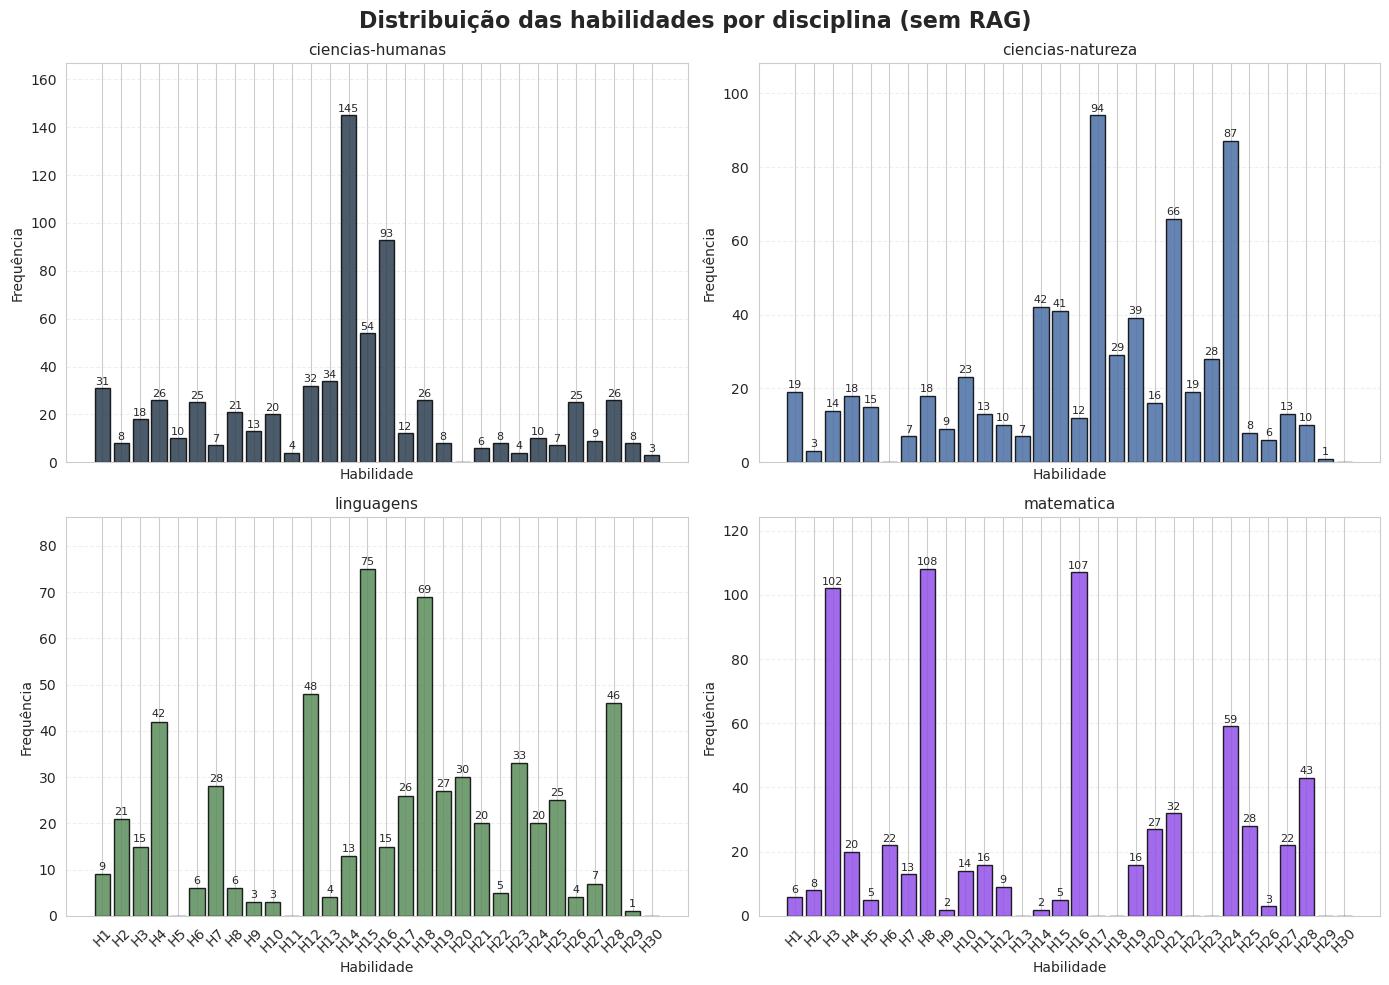

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 10

cores = {
    "ciencias-humanas": "#2c3e50",
    "ciencias-natureza": "#4a6fa5",
    "linguagens": "#5b8c5a",
    "matematica": "#9151e9"
}

coluna_plot = "habilidade_principal"

def plot_distribuicao(df_plot, titulo):

    disciplinas = sorted(df_plot["discipline"].unique())

    # Lista ordenada de todas as habilidades presentes no dataframe
    habilidades = sorted(
        df_plot[coluna_plot].dropna().unique(),
        key=lambda x: int(x.replace("H", ""))
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
        sharex=True
    )

    axes = axes.flatten()

    for i, disciplina in enumerate(disciplinas):

        ax = axes[i]

        dados = df_plot[df_plot["discipline"] == disciplina]

        contagens = (
            dados[coluna_plot]
            .value_counts()
            .reindex(habilidades, fill_value=0)
        )

        bars = ax.bar(
            habilidades,
            contagens.values,
            color=cores.get(disciplina, "gray"),
            edgecolor="black",
            alpha=0.85
        )

        # valores sobre as barras
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.5,
                    f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

        ax.set_title(disciplina, fontsize=11)
        ax.set_xlabel("Habilidade")
        ax.set_ylabel("Frequência")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        ax.tick_params(axis="x", rotation=45)

        if len(contagens):
            ax.set_ylim(0, contagens.max() * 1.15)

    # Remove eixos vazios
    for j in range(len(disciplinas), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(titulo, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_distribuicao(
    df_resultado,
    "Distribuição das habilidades por disciplina (sem RAG)"
)

In [92]:
indices_rag = df_resultado_rag["index"].unique()

df_rag = (
    df_resultado[
        df_resultado["index"].isin(indices_rag)
    ]
    .copy()
)

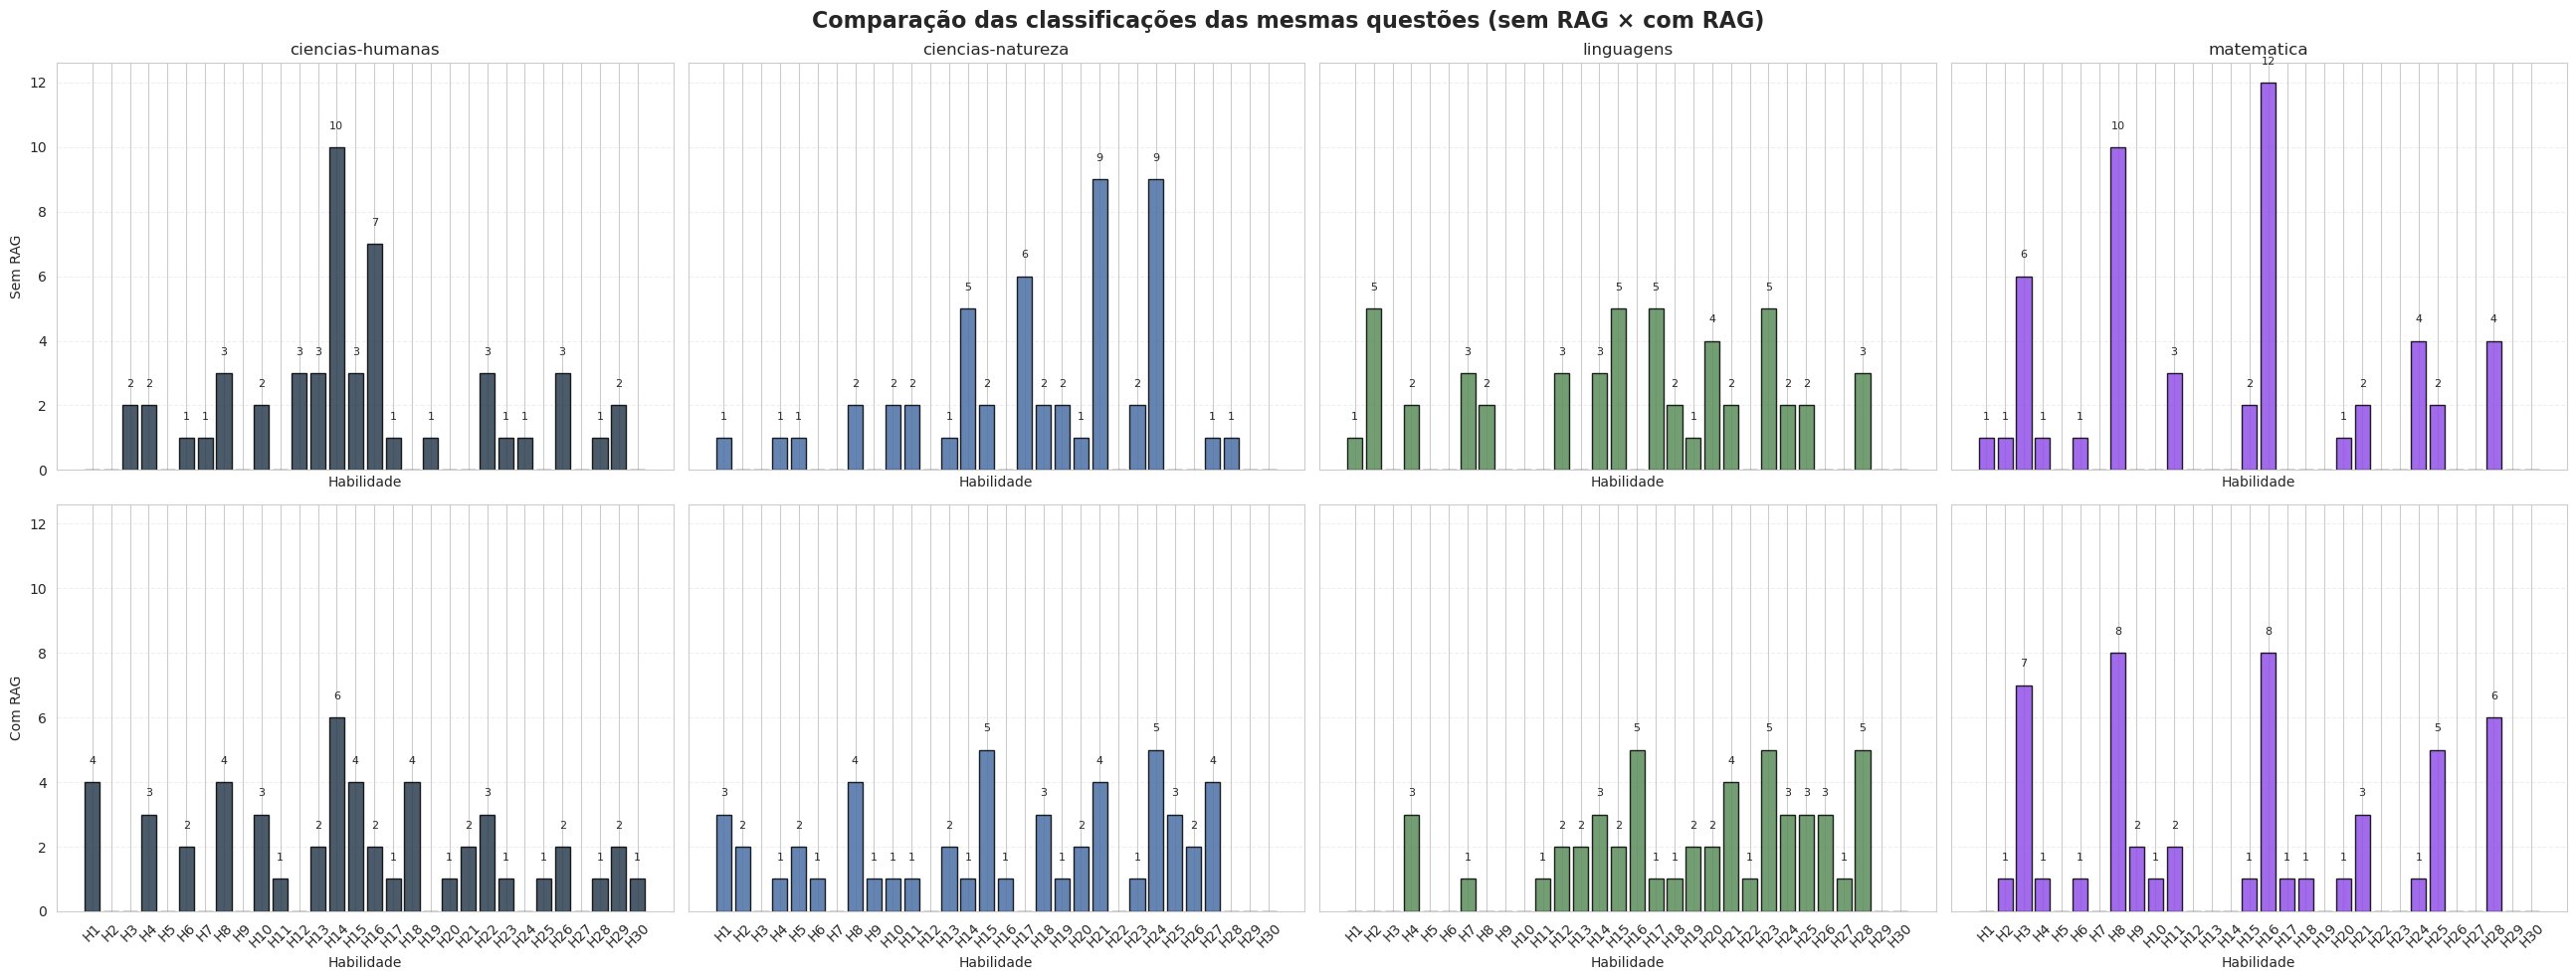

In [105]:
# Lista fixa de habilidades (ordenadas corretamente)
habilidades = sorted(
    set(df_rag["habilidade_principal"].dropna().unique())
    | set(df_resultado_rag["habilidade_principal"].dropna().unique()),
    key=lambda x: int(x[1:])
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(26,10),
    sharey=True,
    sharex=True
)

disciplinas = sorted(df_rag["discipline"].unique())

for linha, (titulo, df_plot) in enumerate([
    ("Sem RAG", df_rag),
    ("Com RAG", df_resultado_rag)
]):

    for coluna, disciplina in enumerate(disciplinas):

        ax = axes[linha, coluna]

        dados = df_plot[df_plot["discipline"] == disciplina]

        contagens = (
            dados[coluna_plot]
            .value_counts()
            .reindex(habilidades, fill_value=0)
        )

        bars = ax.bar(
            habilidades,
            contagens.values,
            color=cores.get(disciplina, "gray"),
            edgecolor="black",
            alpha=0.85
        )

        # Mostrar apenas valores maiores que zero
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.5,
                    str(int(h)),
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

        if linha == 0:
            ax.set_title(disciplina)

        if coluna == 0:
            ax.set_ylabel(titulo)

        ax.set_xlabel("Habilidade")
        ax.set_xticks(range(len(habilidades)))
        ax.set_xticklabels(habilidades, rotation=45)

        ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle(
    "Comparação das classificações das mesmas questões (sem RAG × com RAG)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [107]:
df_resultado_rag.shape

(200, 10)

In [108]:
comparacao = df_rag.merge(
    df_resultado_rag,
    on="index",
    suffixes=('_sem_rag', '_com_rag')
)

comparacao['concorda'] = comparacao['habilidade_principal_sem_rag'] == comparacao['habilidade_principal_com_rag']

taxa_geral = comparacao['concorda'].mean()
print(f"Total comparado: {len(comparacao)} questões")
print(f"Concordância geral: {taxa_geral:.1%}")

taxa_por_area = comparacao.groupby('discipline_sem_rag')['concorda'].mean()
print(taxa_por_area)

Total comparado: 200 questões
Concordância geral: 33.0%
discipline_sem_rag
ciencias-humanas     0.34
ciencias-natureza    0.32
linguagens           0.28
matematica           0.38
Name: concorda, dtype: float64


### Devido a grande discordância o proximo passo será a verificação manual e pessoal de uma amostra 

In [109]:
divergentes = comparacao[~comparacao['concorda']].sample(15, random_state=42)

for _, linha in divergentes.iterrows():
    print(f"\n{'='*80}")
    print(f"Questão {linha['index']}")
    print(f"Sem RAG → {linha['habilidade_principal_sem_rag']}: {linha['descricao_principal_sem_rag']}")
    print(f"Com RAG → {linha['habilidade_principal_com_rag']}: {linha['descricao_principal_com_rag']}")
    print(f"Confiança sem RAG: {linha['confianca_sem_rag']:.2f} | Confiança com RAG: {linha['confianca_com_rag']:.2f}")


Questão 2897
Sem RAG → H25: Resolver problema com dados apresentados em tabelas ou gráficos.
Com RAG → H20: Interpretar gráfico cartesiano que represente relações entre grandezas.
Confiança sem RAG: 0.95 | Confiança com RAG: 1.00

Questão 2691
Sem RAG → H15: Estabelecer relações entre o texto literário e o momento de sua produção, situando aspectos do contexto histórico, social e político.
Com RAG → H11: Reconhecer a linguagem corporal como meio de interação social, considerando os limites de desempenho e as alternativas de adaptação para diferentes indivíduos.
Confiança sem RAG: 0.90 | Confiança com RAG: 0.95

Questão 2815
Sem RAG → H17: Analisar diferentes processos de produção ou circulação de riquezas e suas implicações sócio-espaciais.
Com RAG → H8: Analisar a ação dos estados nacionais no que se refere à dinâmica dos fluxos populacionais e no enfrentamento de problemas de ordem econômico-social.
Confiança sem RAG: 0.95 | Confiança com RAG: 0.95

Questão 2552
Sem RAG → H2: Recorr

In [126]:
print(df.loc[df["index"] == 2615, "context"].iloc[0])
df[df["index"] == 2615]

O petróleo é uma matéria-prima muito valiosa e métodos geofísicos são úteis na sua prospecção. É possível identificar a composição de materiais estratificados medindo-se a velocidade de propagação do som (onda mecânica) através deles. Considere que uma camada de 450 m de um líquido se encontra presa no subsolo entre duas camadas rochosas, conforme o esquema. Um pulso acústico (que gera uma vibração mecânica) é emitido a partir da superfície do solo, onde são posteriormente recebidas duas vibrações refletidas (ecos). A primeira corresponde à reflexão do pulso na interface superior do líquido com a camada rochosa. A segunda vibração deve-se à reflexão do pulso na interface inferior. O tempo entre a emissão do pulso e a chegada do primeiro eco é de 0,5 s. O segundo eco chega 1,1 s após a emissão do pulso [FIGURA] A velocidade do som na camada líquida, em metro por segundo, é


,discipline,context,correctIndex,resposta_correta,index,area
2480,ciencias-natureza,O petróleo é uma matéria-prima muito valiosa e...,3.0,1 500.,2615,Ciências da Natureza e suas Tecnologias


### Resultado da avaliação manual

2897 - SEM RAG
2691 - SEM RAG
2815 - SEM RAG
2552 - Com RAG
2611 - SEM RAG 
2665 - ERRO TOTAL
2511 - COM RAG
2839 - Com RAG
2797 - SEM RAG
2800 - COM RAG
2615 - COM RAG
2608 - COM RAG
2576 - Com RAG
2627 - COM RAG
2713 - COM RAG


COM RAG 9 x 5 Sem RAG e um erro completo

## Conclusão e próximos passos

A extensão com RAG (busca vetorial via ChromaDB, reduzindo de 30 para 8 habilidades candidatas por questão) mostrou dois resultados principais nesta comparação:

- **Tempo**: ~25% mais rápido por questão (46,94s vs. 62,37s).
- **Qualidade**: em uma amostra de 15 casos onde as duas versões discordaram, avaliados manualmente contra o enunciado completo, o RAG acertou 9 e a versão sem RAG acertou 5 (1 caso inconclusivo). O padrão observado foi que a versão sem RAG comete mais erros categóricos — por exemplo, escolher uma habilidade de Língua Estrangeira Moderna para um texto em português — que a pré-seleção semântica do RAG evita.

Esses resultados são promissores, mas vêm de uma amostra ainda limitada (200 questões, com avaliação manual em apenas 15 casos divergentes). Os próximos passos são:

- Testar `n_results=12` (em vez de 8), para avaliar se recuperar mais candidatos reduz ainda mais os casos de discordância sem comprometer o ganho de velocidade.
- Aplicar a versão com RAG ao dataset completo (~2.937 questões), hoje só validada em amostra.
- Ampliar a avaliação manual para uma amostra maior, de forma a consolidar estatisticamente a vantagem observada do RAG nesta primeira rodada.